<a href="https://colab.research.google.com/github/nahidislam106/Recommendation-System-Backend-API/blob/main/complete_pipeline_for_soil_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("✅ Running in Google Colab")
except:
    IN_COLAB = False
    print("ℹ️ Running in local environment")

# Install any additional packages if needed (most are pre-installed in Colab)
if IN_COLAB:
    print("📦 All required packages are already installed in Colab!")
else:
    print("💡 Make sure you have installed: scikit-learn, pandas, numpy, matplotlib, seaborn, joblib")

✅ Running in Google Colab
📦 All required packages are already installed in Colab!


# Crop Recommendation System - Complete ML Pipeline

**🚀 Optimized for Google Colab**

This notebook contains the complete machine learning pipeline for:
1. **Forward Prediction**: Given parameters → Predict recommended crop
2. **Reverse Prediction**: Given crop → Predict ideal parameter values

## Dataset Features
- N, P, K: Soil nutrients (kg/ha)
- temperature, humidity, ph, EC: Soil conditions
- weather_temperature, weather_humidity: Weather conditions
- light_intensity, air_pressure, rainfall: Environmental factors
- crop: Target variable (crop type)

## Quick Start (Colab)
1. Upload your dataset in the cells below
2. Run all cells sequentially
3. Download trained models at the end

In [2]:
# Verify dataset is available
import os

dataset_path = '/content/useable_dataset - useable_dataset.csv'

if os.path.exists(dataset_path):
    file_size = os.path.getsize(dataset_path) / 1024
    print("✅ Dataset found!")
    print(f"   📁 File: {dataset_path}")
    print(f"   📊 Size: {file_size:.2f} KB")

    # Quick peek at the data
    import pandas as pd
    df_peek = pd.read_csv(dataset_path, nrows=3)
    print(f"   🔢 Columns: {len(df_peek.columns)}")
    print(f"   📋 Sample columns: {', '.join(df_peek.columns[:5].tolist())}")
else:
    print("❌ Dataset not found!")
    if IN_COLAB:
        print("💡 Please run one of the upload cells above to upload your dataset")
    else:
        print(f"💡 Please ensure '{dataset_path}' is in the current directory")

✅ Dataset found!
   📁 File: /content/useable_dataset - useable_dataset.csv
   📊 Size: 225.50 KB
   🔢 Columns: 13
   📋 Sample columns: N, P, K, temperature, humidity


In [ ]:
# Option 2: Mount Google Drive (if dataset is in Drive)
# Run this cell if you prefer to use Google Drive

if IN_COLAB:
    mount_drive = input("Mount Google Drive? (y/n): ").lower() == 'y'

    if mount_drive:
        from google.colab import drive
        drive.mount('/content/drive')

        # Update this path to where your dataset is stored in Google Drive
        drive_path = input("Enter path to dataset in Drive (e.g., /content/drive/MyDrive/dataset.csv): ")

        import shutil
        shutil.copy(drive_path, 'useable_dataset - useable_dataset.csv')
        print("✅ Dataset copied from Google Drive!")
    else:
        print("ℹ️ Skipped Google Drive mount")
else:
    print("ℹ️ This cell is only for Google Colab users")

In [ ]:
# Option 1: Upload dataset directly to Colab
if IN_COLAB:
    from google.colab import files
    import os

    print("📤 Upload your dataset file: useable_dataset - useable_dataset.csv")
    uploaded = files.upload()

    # Rename if needed
    if 'useable_dataset - useable_dataset.csv' not in os.listdir('.'):
        # Get the uploaded filename
        uploaded_file = list(uploaded.keys())[0]
        if uploaded_file != 'useable_dataset - useable_dataset.csv':
            os.rename(uploaded_file, 'useable_dataset - useable_dataset.csv')
            print(f"✅ Renamed '{uploaded_file}' to 'useable_dataset - useable_dataset.csv'")

    print("✅ Dataset uploaded successfully!")
else:
    print("ℹ️ Skipping upload - not in Colab environment")
    print("💡 Make sure 'useable_dataset - useable_dataset.csv' is in the same directory")

## 🔷 Google Colab Setup

**Instructions for running in Google Colab:**

1. Upload this notebook to Google Colab
2. Run the cell below to upload your dataset
3. Or mount Google Drive if you have the dataset there
4. Continue with the rest of the notebook

## 1. Import Libraries

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Models
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, mean_squared_error, r2_score
)

# Model Persistence
import joblib
import json
from pathlib import Path

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load and Explore Data

In [4]:
# Load dataset
df = pd.read_csv('/content/useable_dataset - useable_dataset.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (2601, 13)

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'EC', 'weather_temperature', 'weather_humidity', 'light_intensity', 'air_pressure', 'rainfall', 'crop']

First 5 rows:


,N,P,K,temperature,humidity,ph,EC,weather_temperature,weather_humidity,light_intensity,air_pressure,rainfall,crop
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,3.36,20.31,63.72,381.97,997.77,2.64,rice
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,2.25,15.85,73.57,839.16,989.62,16.79,rice
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,3.18,27.10,83.84,946.68,1028.62,23.56,rice
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,2.57,23.20,93.93,660.43,1011.05,8.78,rice
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,1.70,20.57,66.74,510.01,999.20,24.18,rice


In [5]:
# Dataset info
print("Dataset Information:")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("Missing Values:")
print(df.isnull().sum())

print("\n" + "=" * 60)
print("Statistical Summary:")
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2601 entries, 0 to 2600
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   N                    2601 non-null   float64
 1   P                    2601 non-null   float64
 2   K                    2601 non-null   float64
 3   temperature          2601 non-null   float64
 4   humidity             2601 non-null   float64
 5   ph                   2601 non-null   float64
 6   EC                   2601 non-null   float64
 7   weather_temperature  2601 non-null   float64
 8   weather_humidity     2601 non-null   float64
 9   light_intensity      2601 non-null   float64
 10  air_pressure         2601 non-null   float64
 11  rainfall             2601 non-null   float64
 12  crop                 2601 non-null   object 
dtypes: float64(12), object(1)
memory usage: 264.3+ KB

Missing Values:
N                      0
P                      0


,N,P,K,temperature,humidity,ph,EC,weather_temperature,weather_humidity,light_intensity,air_pressure,rainfall
count,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.000000,2601.00000
mean,43.653326,47.872587,43.374510,26.519313,63.790708,5.788085,3.002907,19.423691,71.841803,548.624591,1004.962418,14.99128
std,37.717779,34.006932,48.640621,5.219355,27.487912,1.801541,1.531639,4.944208,13.997441,257.140347,14.349264,8.63370
min,0.000000,0.000000,0.000000,8.825675,0.000000,0.237129,1.200000,11.000000,47.020000,100.990000,980.040000,0.04000
25%,13.000000,21.000000,18.000000,23.357232,43.614441,5.667420,1.950000,15.190000,59.930000,325.050000,992.850000,7.35000
50%,31.000000,45.000000,28.000000,26.587407,72.605129,6.271479,2.640000,19.300000,72.060000,543.280000,1005.020000,15.04000
75%,78.000000,65.000000,47.000000,29.527531,87.451267,6.813383,3.340000,23.690000,83.790000,771.540000,1017.320000,22.42000
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,7.500000,28.000000,95.980000,999.960000,1029.990000,30.00000


Crop Distribution:
crop
Chili           101
Cucumber        101
chickpea        100
kidneybeans     100
pigeonpeas      100
mothbeans       100
mungbean        100
blackgram       100
rice            100
maize           100
pomegranate     100
lentil          100
banana          100
mango           100
muskmelon       100
apple           100
grapes          100
watermelon      100
papaya          100
orange          100
coconut         100
cotton          100
Cauliflower     100
jute            100
Balsam Apple    100
coffee           99
Name: count, dtype: int64


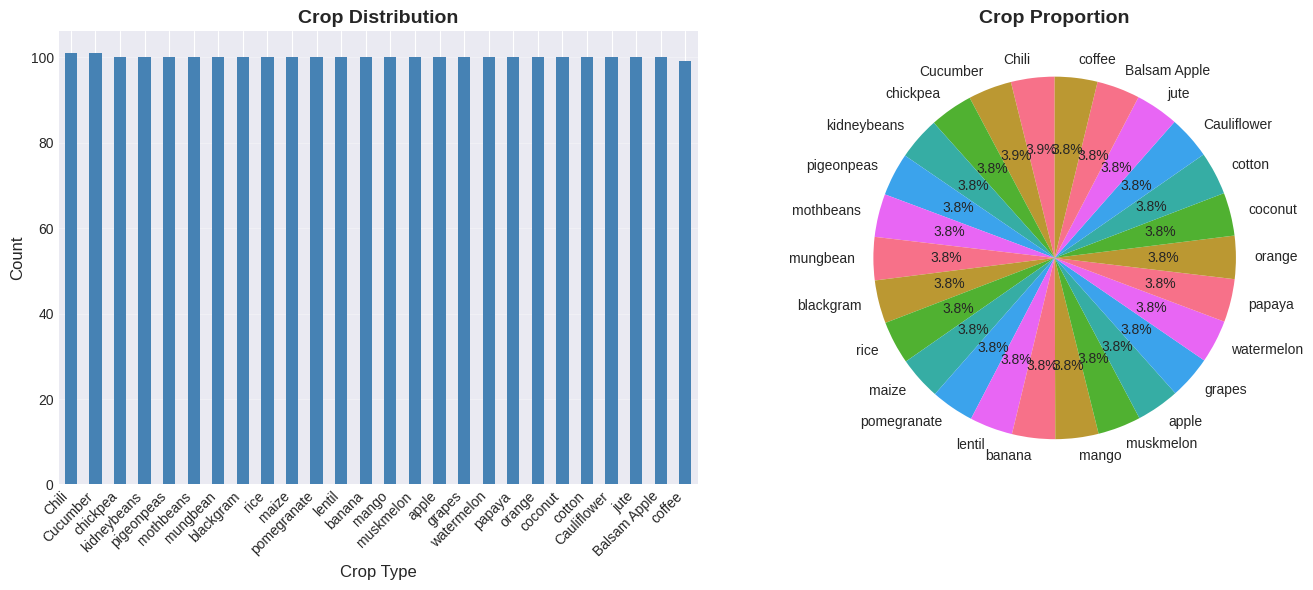


Total Crops: 26


In [6]:
# Check crop distribution
print("Crop Distribution:")
print("=" * 60)
crop_counts = df['crop'].value_counts()
print(crop_counts)

# Visualize crop distribution
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
crop_counts.plot(kind='bar', color='steelblue')
plt.title('Crop Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Crop Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
crop_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Crop Proportion', fontsize=14, fontweight='bold')
plt.ylabel('')

plt.tight_layout()
plt.show()

print(f"\nTotal Crops: {df['crop'].nunique()}")

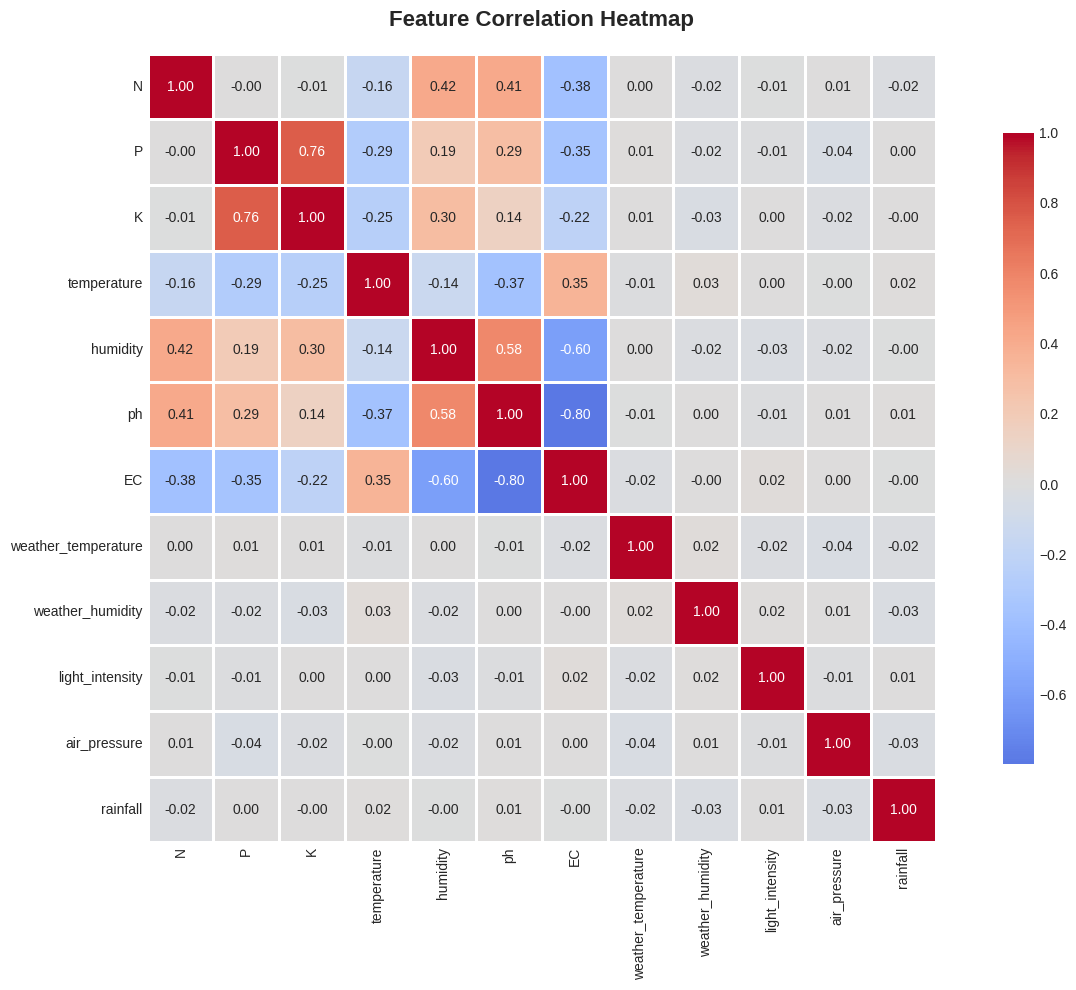

In [7]:
# Feature correlation heatmap
plt.figure(figsize=(14, 10))

# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [8]:
# Separate features and target
feature_columns = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'EC',
                   'weather_temperature', 'weather_humidity', 'light_intensity',
                   'air_pressure', 'rainfall']

X = df[feature_columns]
y = df['crop']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {feature_columns}")
print(f"\nUnique crops: {y.nunique()}")
print(f"Crop types: {sorted(y.unique())}")

Features shape: (2601, 12)
Target shape: (2601,)

Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'EC', 'weather_temperature', 'weather_humidity', 'light_intensity', 'air_pressure', 'rainfall']

Unique crops: 26
Crop types: ['Balsam Apple', 'Cauliflower', 'Chili', 'Cucumber', 'apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


In [9]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set crop distribution:")
print(y_train.value_counts())

Training set size: 2080 samples
Test set size: 521 samples

Training set crop distribution:
crop
Chili           81
orange          80
maize           80
pigeonpeas      80
coconut         80
mothbeans       80
banana          80
muskmelon       80
lentil          80
mungbean        80
mango           80
Cucumber        80
rice            80
papaya          80
kidneybeans     80
cotton          80
watermelon      80
Balsam Apple    80
Cauliflower     80
apple           80
pomegranate     80
jute            80
chickpea        80
blackgram       80
grapes          80
coffee          79
Name: count, dtype: int64


In [10]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed")
print(f"\nScaled features mean (should be ~0): {X_train_scaled.mean():.6f}")
print(f"Scaled features std (should be ~1): {X_train_scaled.std():.6f}")

✅ Feature scaling completed

Scaled features mean (should be ~0): 0.000000
Scaled features std (should be ~1): 1.000000


## 4. Model Training - Forward Prediction (Parameters → Crop)

In [11]:
# Define models to compare
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42, probability=True)
}

print("Models to be trained:")
for name in models.keys():
    print(f"  • {name}")

Models to be trained:
  • Random Forest
  • Decision Tree
  • Logistic Regression
  • K-Nearest Neighbors
  • Support Vector Machine


In [12]:
# Train and evaluate all models
results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print('='*60)

    # Train model
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted')

    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, n_jobs=-1)
    cv_mean = cv_scores.mean()

    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'cv_score': cv_mean,
        'y_pred': y_pred
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Cross-Validation Score: {cv_mean:.4f}")

print("\n✅ All models trained successfully!")


Training: Random Forest
Accuracy: 0.9731
F1 Score: 0.9731
Precision: 0.9739
Recall: 0.9731
Cross-Validation Score: 0.9635

Training: Decision Tree
Accuracy: 0.9520
F1 Score: 0.9518
Precision: 0.9536
Recall: 0.9520
Cross-Validation Score: 0.9428

Training: Logistic Regression
Accuracy: 0.8983
F1 Score: 0.8963
Precision: 0.9001
Recall: 0.8983
Cross-Validation Score: 0.8981

Training: K-Nearest Neighbors
Accuracy: 0.6084
F1 Score: 0.5993
Precision: 0.6267
Recall: 0.6084
Cross-Validation Score: 0.6221

Training: Support Vector Machine
Accuracy: 0.8541
F1 Score: 0.8558
Precision: 0.8646
Recall: 0.8541
Cross-Validation Score: 0.8543

✅ All models trained successfully!



Model Performance Comparison:
                 Model  Accuracy  F1 Score  Precision   Recall  CV Score
         Random Forest  0.973129  0.973093   0.973897 0.973129  0.963462
         Decision Tree  0.952015  0.951770   0.953581 0.952015  0.942788
   Logistic Regression  0.898273  0.896307   0.900097 0.898273  0.898077
Support Vector Machine  0.854127  0.855751   0.864551 0.854127  0.854327
   K-Nearest Neighbors  0.608445  0.599295   0.626724 0.608445  0.622115


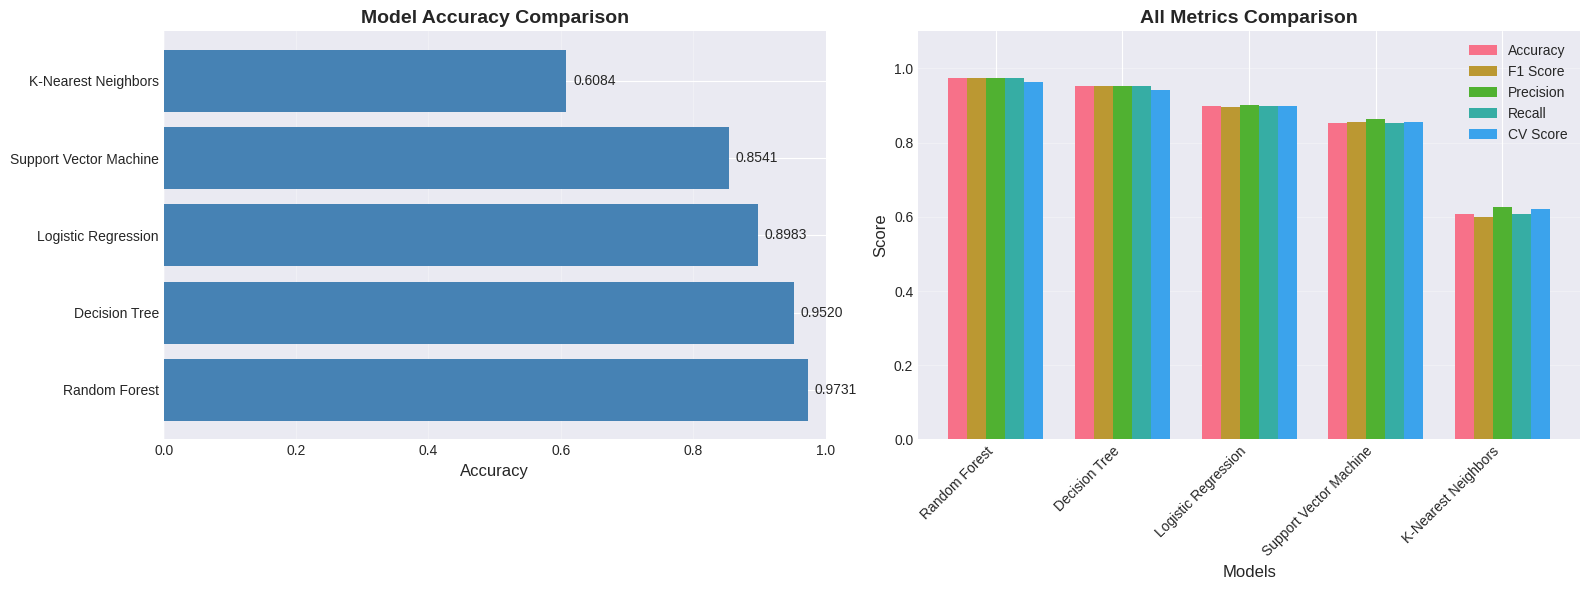


🏆 Best Model: Random Forest
   Accuracy: 0.9731


In [13]:
# Compare model performance
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[m]['accuracy'] for m in results.keys()],
    'F1 Score': [results[m]['f1_score'] for m in results.keys()],
    'Precision': [results[m]['precision'] for m in results.keys()],
    'Recall': [results[m]['recall'] for m in results.keys()],
    'CV Score': [results[m]['cv_score'] for m in results.keys()]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\nModel Performance Comparison:")
print("=" * 100)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
axes[0].barh(comparison_df['Model'], comparison_df['Accuracy'], color='steelblue')
axes[0].set_xlabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_xlim([0, 1])
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(comparison_df['Accuracy']):
    axes[0].text(v + 0.01, i, f'{v:.4f}', va='center')

# All metrics comparison
metrics = ['Accuracy', 'F1 Score', 'Precision', 'Recall', 'CV Score']
x = np.arange(len(comparison_df))
width = 0.15

for i, metric in enumerate(metrics):
    axes[1].bar(x + i*width, comparison_df[metric], width, label=metric)

axes[1].set_xlabel('Models', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x + width * 2)
axes[1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

# Select best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Accuracy: {comparison_df.iloc[0]['Accuracy']:.4f}")

In [14]:
# Detailed classification report for best model
print(f"\nClassification Report for {best_model_name}:")
print("=" * 80)
print(classification_report(y_test, results[best_model_name]['y_pred']))


Classification Report for Random Forest:
              precision    recall  f1-score   support

Balsam Apple       1.00      1.00      1.00        20
 Cauliflower       0.95      1.00      0.98        20
       Chili       1.00      1.00      1.00        20
    Cucumber       1.00      0.95      0.98        21
       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.86      0.95      0.90        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.81      0.85      0.83        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.85      0.92        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      

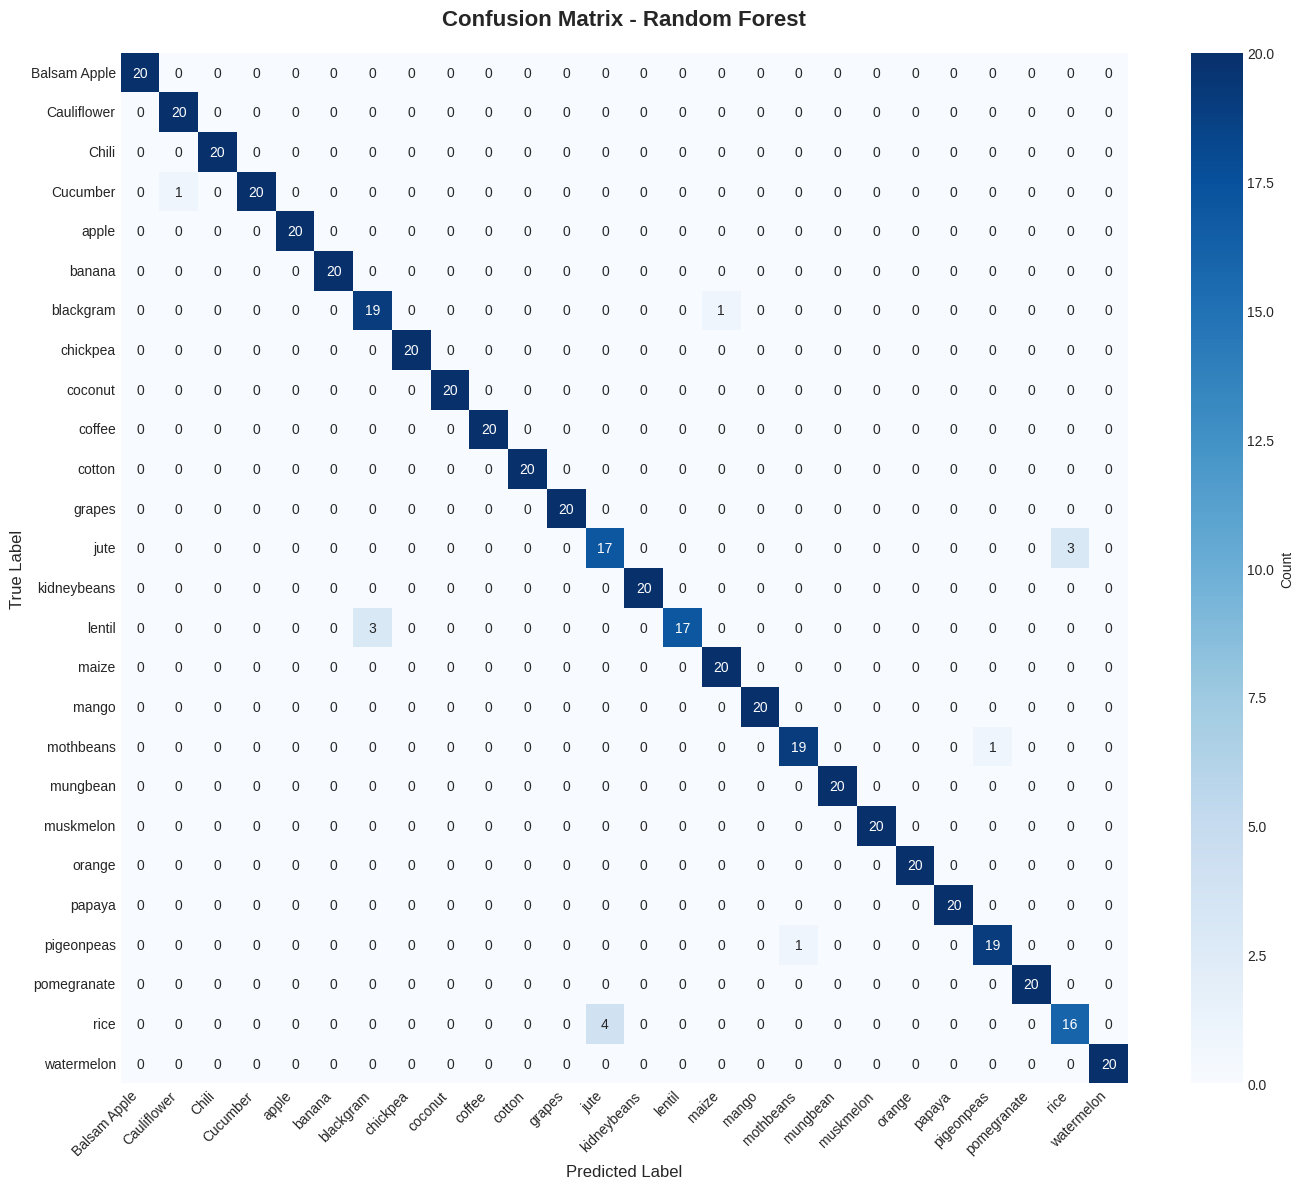

In [15]:
# Confusion Matrix for best model
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
crop_labels = sorted(y.unique())

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=crop_labels, yticklabels=crop_labels,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

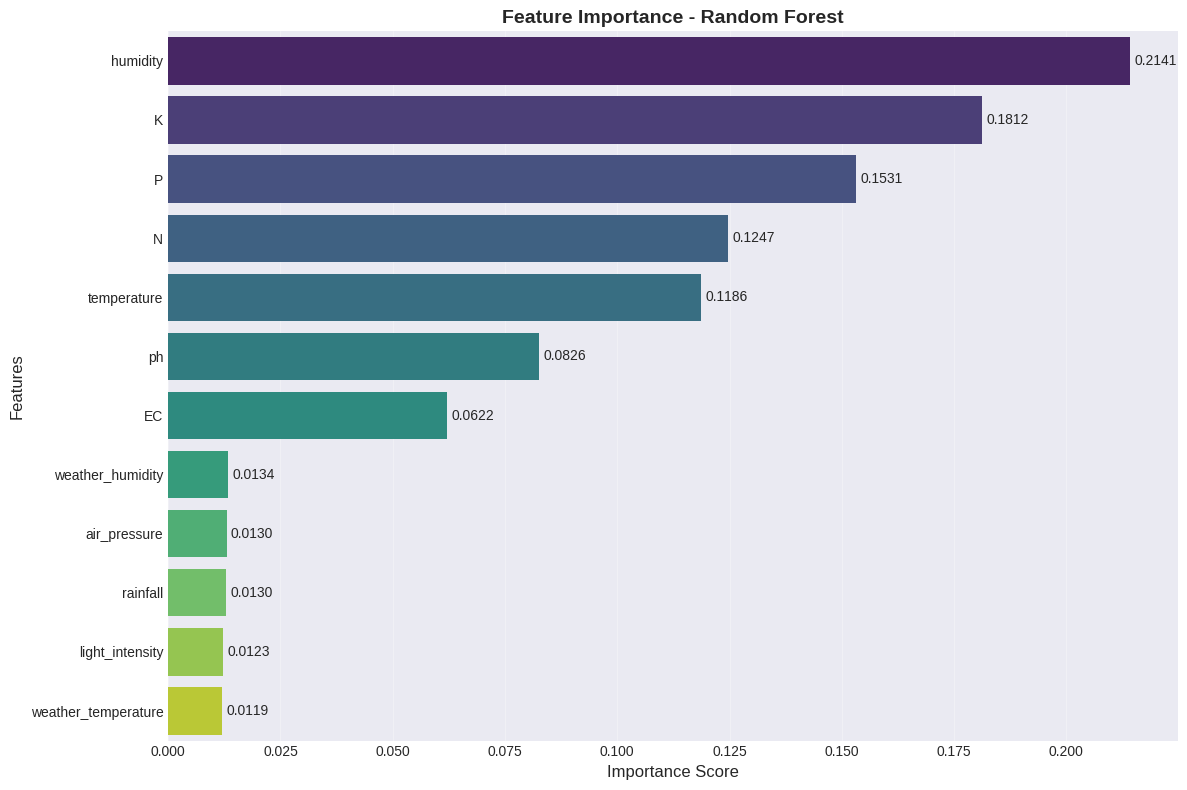


Top 5 Important Features:
       Feature  Importance
4     humidity    0.214100
2            K    0.181243
1            P    0.153124
0            N    0.124685
3  temperature    0.118603


In [16]:
# Feature importance (for Random Forest)
if best_model_name == 'Random Forest':
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
    plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
    plt.xlabel('Importance Score', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.grid(axis='x', alpha=0.3)

    for i, v in enumerate(feature_importance['Importance']):
        plt.text(v + 0.001, i, f'{v:.4f}', va='center')

    plt.tight_layout()
    plt.show()

    print("\nTop 5 Important Features:")
    print(feature_importance.head())

## 5. Reverse Model - Predict Ideal Parameters for Each Crop

In [17]:
# Calculate ideal parameter values for each crop (mean values)
ideal_parameters = df.groupby('crop')[feature_columns].agg(['mean', 'std', 'min', 'max']).round(2)

print("Ideal Parameter Ranges by Crop:")
print("=" * 100)
print(ideal_parameters)

# Save as a more readable format
ideal_params_dict = {}
for crop in df['crop'].unique():
    crop_data = df[df['crop'] == crop][feature_columns]
    ideal_params_dict[crop] = {
        feature: {
            'mean': float(crop_data[feature].mean()),
            'std': float(crop_data[feature].std()),
            'min': float(crop_data[feature].min()),
            'max': float(crop_data[feature].max()),
            'median': float(crop_data[feature].median())
        }
        for feature in feature_columns
    }

print("\n✅ Ideal parameters calculated for all crops")

Ideal Parameter Ranges by Crop:
                   N                            P                       \
                mean    std    min    max    mean    std    min    max   
crop                                                                     
Balsam Apple   19.27   8.44    0.0   26.5   48.96  20.06    0.0   66.0   
Cauliflower     0.57   0.58    0.0    1.4    4.33   3.25    0.0    7.8   
Chili           0.96   0.44    0.0    1.5    6.51   2.07    0.0    8.1   
Cucumber        3.48   3.87    0.0    9.4   11.39  10.24    0.0   26.5   
apple          20.80  11.86    0.0   40.0  134.22   8.14  120.0  145.0   
banana        100.23  11.11   80.0  120.0   82.01   7.69   70.0   95.0   
blackgram      40.02  12.66   20.0   60.0   67.47   7.15   55.0   80.0   
chickpea       40.09  12.15   20.0   60.0   67.79   7.50   55.0   80.0   
coconut        21.98  11.76    0.0   40.0   16.93   8.36    5.0   30.0   
coffee        101.17  12.40   80.0  120.0   28.85   7.23   15.0   40.0   
cotton


Ideal Parameters for CHILI:
                            mean         std         min          max       median
N                       0.957426    0.443700    0.000000     1.500000     0.900000
P                       6.510891    2.071082    0.000000     8.100000     6.900000
K                       5.811881    1.879962    0.000000     7.400000     6.100000
temperature            34.548515    1.720501   32.000000    35.900000    35.800000
humidity               20.271287    2.320446    6.300000    22.400000    20.500000
ph                      2.011989    1.124434    0.237129     3.949318     2.025926
EC                      5.472277    0.418358    3.000000     6.200000     5.500000
weather_temperature    19.163663    5.239286   11.320000    27.940000    18.740000
weather_humidity       72.656337   15.406875   47.830000    95.920000    75.520000
light_intensity       555.395347  262.904274  109.300000   990.580000   586.790000
air_pressure         1004.677030   14.910042  980.880000  

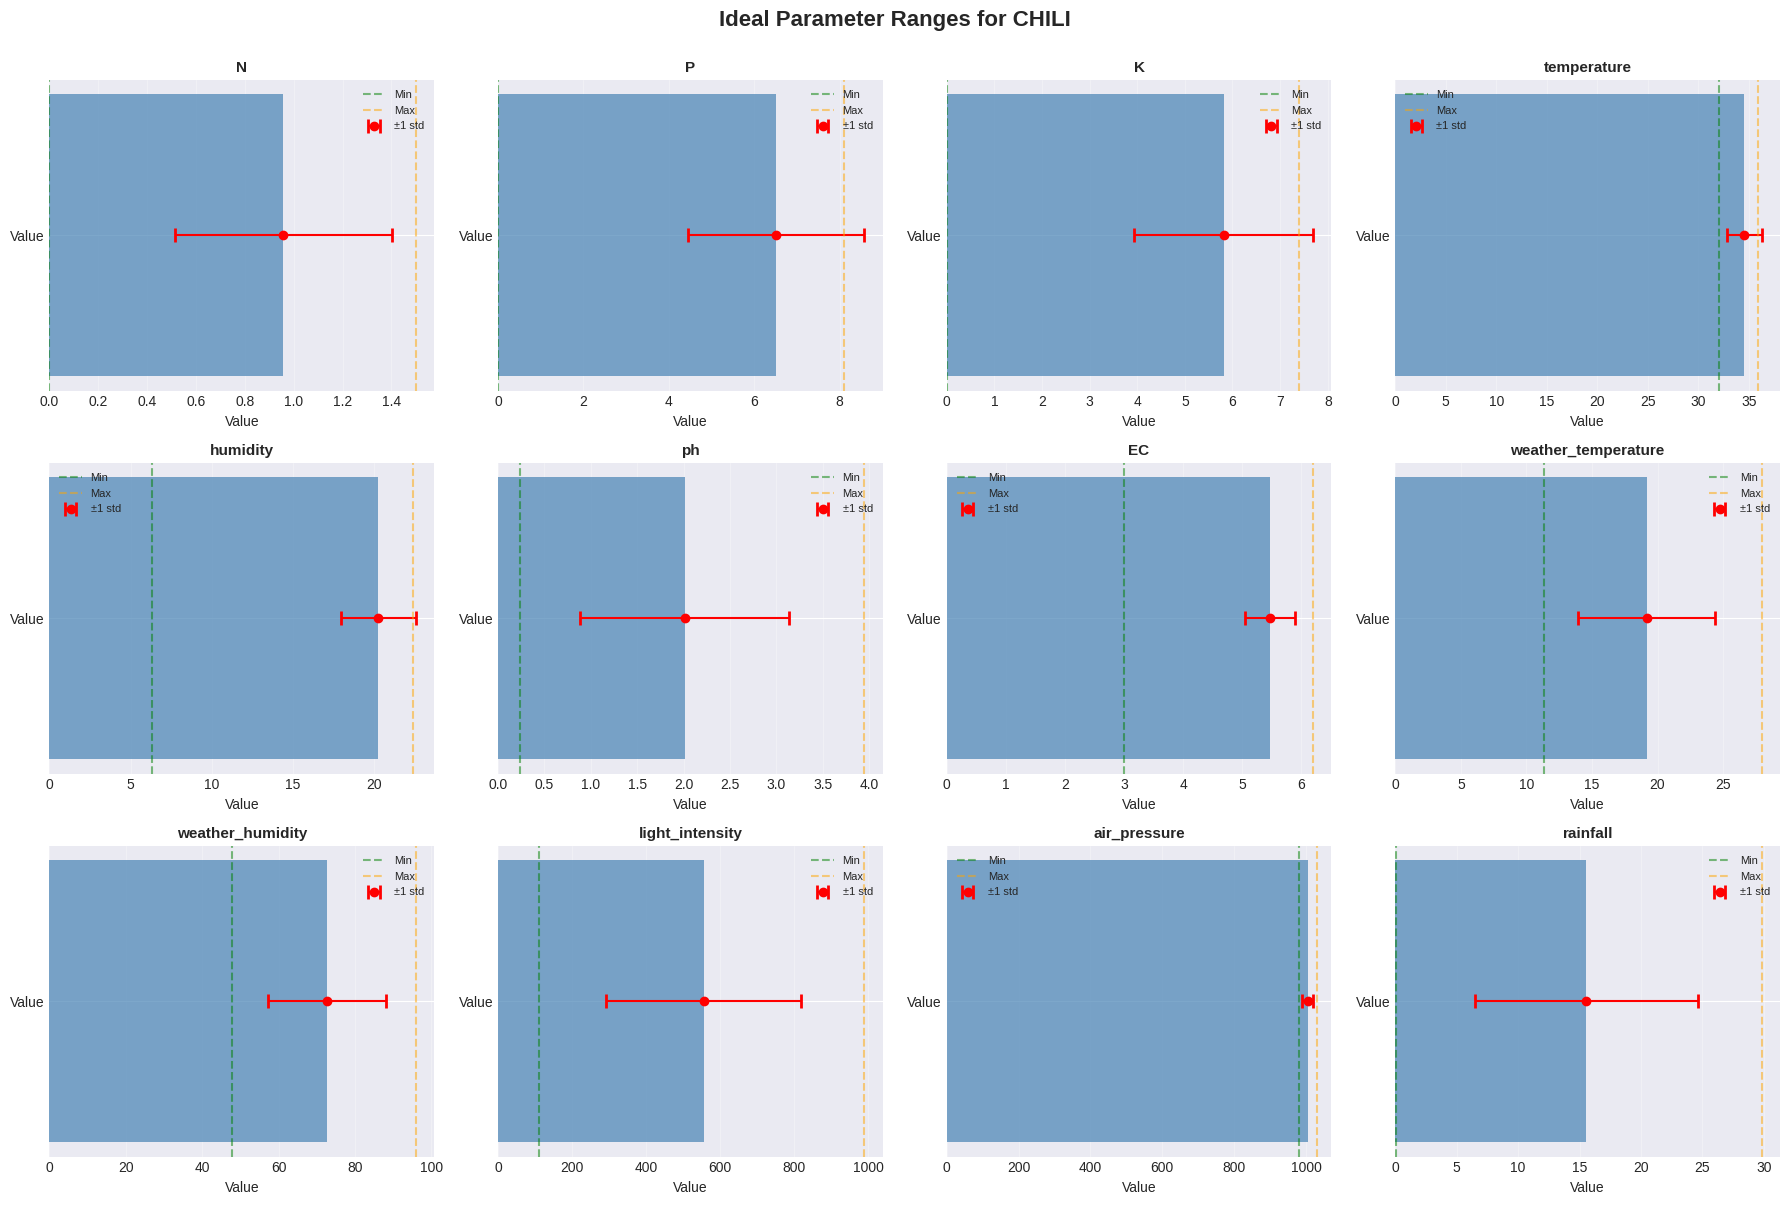

In [18]:
# Example: Show ideal parameters for a specific crop
example_crop = df['crop'].value_counts().index[0]  # Most common crop

print(f"\nIdeal Parameters for {example_crop.upper()}:")
print("=" * 80)

ideal_df = pd.DataFrame(ideal_params_dict[example_crop]).T
print(ideal_df.to_string())

# Visualize ideal ranges
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(feature_columns):
    data = ideal_df.loc[feature]

    axes[idx].barh(['Value'], [data['mean']], color='steelblue', alpha=0.7)
    axes[idx].errorbar(data['mean'], 0, xerr=data['std'], fmt='o', color='red',
                       capsize=5, capthick=2, label='±1 std')
    axes[idx].axvline(data['min'], color='green', linestyle='--', alpha=0.5, label='Min')
    axes[idx].axvline(data['max'], color='orange', linestyle='--', alpha=0.5, label='Max')
    axes[idx].set_title(f'{feature}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].legend(fontsize=8, loc='best')
    axes[idx].grid(axis='x', alpha=0.3)

plt.suptitle(f'Ideal Parameter Ranges for {example_crop.upper()}',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [19]:
# Train regression models to predict parameter values given a crop
# This allows dynamic prediction instead of just using mean values

# Encode crop labels for regression
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Store regression models for each parameter
reverse_models = {}

print("Training Reverse Prediction Models (Crop → Parameters):")
print("=" * 80)

for feature in feature_columns:
    # Create model for each parameter
    model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

    # Train on encoded crop labels to predict parameter values
    X_reverse = y_encoded.reshape(-1, 1)
    y_reverse = df[feature].values

    # Split data
    X_rev_train, X_rev_test, y_rev_train, y_rev_test = train_test_split(
        X_reverse, y_reverse, test_size=0.2, random_state=42
    )

    # Train model
    model.fit(X_rev_train, y_rev_train)

    # Evaluate
    y_rev_pred = model.predict(X_rev_test)
    r2 = r2_score(y_rev_test, y_rev_pred)
    rmse = np.sqrt(mean_squared_error(y_rev_test, y_rev_pred))

    reverse_models[feature] = {
        'model': model,
        'r2_score': r2,
        'rmse': rmse
    }

    print(f"{feature:25s} - R² Score: {r2:.4f}, RMSE: {rmse:.4f}")

print("\n✅ Reverse prediction models trained successfully!")

Training Reverse Prediction Models (Crop → Parameters):
N                         - R² Score: 0.9153, RMSE: 11.0188
P                         - R² Score: 0.9438, RMSE: 8.1269
K                         - R² Score: 0.9894, RMSE: 5.1166
temperature               - R² Score: 0.6051, RMSE: 3.3510
humidity                  - R² Score: 0.9663, RMSE: 5.0242
ph                        - R² Score: 0.8262, RMSE: 0.7563
EC                        - R² Score: 0.8154, RMSE: 0.6666
weather_temperature       - R² Score: -0.0092, RMSE: 4.9680
weather_humidity          - R² Score: -0.0031, RMSE: 13.8785
light_intensity           - R² Score: -0.0148, RMSE: 261.1475
air_pressure              - R² Score: -0.0054, RMSE: 14.7393
rainfall                  - R² Score: -0.0112, RMSE: 8.9959

✅ Reverse prediction models trained successfully!


## 6. Test Both Models

In [20]:
# Test Forward Prediction: Parameters → Crop
print("Test Forward Prediction (Parameters → Crop):")
print("=" * 80)

# Example input
sample_input = {
    'N': 90, 'P': 42, 'K': 43,
    'temperature': 20.88, 'humidity': 82.0,
    'ph': 6.5, 'EC': 3.36,
    'weather_temperature': 20.31,
    'weather_humidity': 63.72,
    'light_intensity': 381.97,
    'air_pressure': 997.77,
    'rainfall': 2.64
}

# Convert to DataFrame
input_df = pd.DataFrame([sample_input])
input_scaled = scaler.transform(input_df)

# Predict
predicted_crop = best_model.predict(input_scaled)[0]
confidence = best_model.predict_proba(input_scaled).max()

print(f"Input Parameters:")
for k, v in sample_input.items():
    print(f"  {k:25s}: {v}")

print(f"\n🌾 Recommended Crop: {predicted_crop.upper()}")
print(f"   Confidence: {confidence:.2%}")

Test Forward Prediction (Parameters → Crop):
Input Parameters:
  N                        : 90
  P                        : 42
  K                        : 43
  temperature              : 20.88
  humidity                 : 82.0
  ph                       : 6.5
  EC                       : 3.36
  weather_temperature      : 20.31
  weather_humidity         : 63.72
  light_intensity          : 381.97
  air_pressure             : 997.77
  rainfall                 : 2.64

🌾 Recommended Crop: RICE
   Confidence: 93.00%


In [21]:
# Test Reverse Prediction: Crop → Ideal Parameters
print("\nTest Reverse Prediction (Crop → Ideal Parameters):")
print("=" * 80)

# Select a crop
selected_crop = 'rice'
crop_encoded = label_encoder.transform([selected_crop])[0]

print(f"Selected Crop: {selected_crop.upper()}")
print("\nPredicted Ideal Parameters:")
print("-" * 80)

predicted_params = {}
for feature in feature_columns:
    model = reverse_models[feature]['model']
    predicted_value = model.predict([[crop_encoded]])[0]
    predicted_params[feature] = predicted_value

    # Get actual mean from data
    actual_mean = df[df['crop'] == selected_crop][feature].mean()

    print(f"{feature:25s}: {predicted_value:8.2f} (Actual Mean: {actual_mean:8.2f})")

print("\n✅ You can now use these parameters to grow", selected_crop.upper(), "successfully!")


Test Reverse Prediction (Crop → Ideal Parameters):
Selected Crop: RICE

Predicted Ideal Parameters:
--------------------------------------------------------------------------------
N                        :    79.78 (Actual Mean:    79.89)
P                        :    47.17 (Actual Mean:    47.58)
K                        :    39.78 (Actual Mean:    39.87)
temperature              :    23.62 (Actual Mean:    23.69)
humidity                 :    82.25 (Actual Mean:    82.27)
ph                       :     6.36 (Actual Mean:     6.43)
EC                       :     2.43 (Actual Mean:     2.38)
weather_temperature      :    20.32 (Actual Mean:    20.10)
weather_humidity         :    70.15 (Actual Mean:    70.07)
light_intensity          :   526.14 (Actual Mean:   538.50)
air_pressure             :  1005.64 (Actual Mean:  1005.11)
rainfall                 :    15.17 (Actual Mean:    14.77)

✅ You can now use these parameters to grow RICE successfully!


In [22]:
# Create a function to get ideal parameters for any crop
def get_ideal_parameters(crop_name):
    """
    Get ideal parameter values for a given crop

    Args:
        crop_name: Name of the crop

    Returns:
        Dictionary with ideal parameter values and ranges
    """
    crop_name = crop_name.lower()

    if crop_name not in ideal_params_dict:
        available_crops = list(ideal_params_dict.keys())
        return f"Crop '{crop_name}' not found. Available crops: {available_crops}"

    return ideal_params_dict[crop_name]

# Test the function
print("Example: Get ideal parameters for 'maize'")
print("=" * 80)
result = get_ideal_parameters('maize')

if isinstance(result, dict):
    for param, values in result.items():
        print(f"\n{param}:")
        print(f"  Mean: {values['mean']:.2f}")
        print(f"  Range: [{values['min']:.2f} - {values['max']:.2f}]")
        print(f"  Std Dev: {values['std']:.2f}")
else:
    print(result)

Example: Get ideal parameters for 'maize'

N:
  Mean: 77.76
  Range: [60.00 - 100.00]
  Std Dev: 11.95

P:
  Mean: 48.44
  Range: [35.00 - 60.00]
  Std Dev: 8.01

K:
  Mean: 19.79
  Range: [15.00 - 25.00]
  Std Dev: 2.94

temperature:
  Mean: 22.39
  Range: [18.04 - 26.55]
  Std Dev: 2.68

humidity:
  Mean: 65.09
  Range: [55.28 - 74.83]
  Std Dev: 5.45

ph:
  Mean: 6.25
  Range: [5.51 - 7.00]
  Std Dev: 0.41

EC:
  Mean: 2.45
  Range: [1.21 - 3.60]
  Std Dev: 0.71

weather_temperature:
  Mean: 19.15
  Range: [11.04 - 27.89]
  Std Dev: 5.00

weather_humidity:
  Mean: 72.37
  Range: [49.18 - 95.84]
  Std Dev: 12.58

light_intensity:
  Mean: 543.54
  Range: [114.57 - 996.68]
  Std Dev: 253.24

air_pressure:
  Mean: 1004.18
  Range: [980.47 - 1029.87]
  Std Dev: 13.89

rainfall:
  Mean: 14.12
  Range: [0.45 - 29.85]
  Std Dev: 8.75


## 7. Save Models and Data

In [23]:
# Create Model directory
model_dir = Path('Model')
model_dir.mkdir(exist_ok=True)

print("Saving models and artifacts...")
print("=" * 80)

Saving models and artifacts...


In [24]:
# Save forward prediction model (Parameters → Crop)
joblib.dump(best_model, model_dir / 'best_crop_model_joblib.pkl')
print("✅ Saved: best_crop_model_joblib.pkl")

# Save scaler
joblib.dump(scaler, model_dir / 'scaler_joblib.pkl')
print("✅ Saved: scaler_joblib.pkl")

# Save model info
model_info = {
    'model_name': best_model_name,
    'accuracy': float(results[best_model_name]['accuracy']),
    'f1_score': float(results[best_model_name]['f1_score']),
    'cv_score': float(results[best_model_name]['cv_score']),
    'features': feature_columns,
    'n_features': len(feature_columns),
    'crops': sorted(y.unique().tolist()),
    'n_crops': int(y.nunique())
}

joblib.dump(model_info, model_dir / 'model_info.pkl')
print("✅ Saved: model_info.pkl")

✅ Saved: best_crop_model_joblib.pkl
✅ Saved: scaler_joblib.pkl
✅ Saved: model_info.pkl


In [25]:
# Save reverse prediction models (Crop → Parameters)
reverse_models_data = {
    'models': {feature: reverse_models[feature]['model'] for feature in feature_columns},
    'label_encoder': label_encoder,
    'performance': {feature: {
        'r2_score': reverse_models[feature]['r2_score'],
        'rmse': reverse_models[feature]['rmse']
    } for feature in feature_columns}
}

joblib.dump(reverse_models_data, model_dir / 'reverse_prediction_models.pkl')
print("✅ Saved: reverse_prediction_models.pkl")

✅ Saved: reverse_prediction_models.pkl


In [26]:
# Save ideal parameters dictionary as JSON
with open(model_dir / 'ideal_parameters.json', 'w') as f:
    json.dump(ideal_params_dict, f, indent=2)
print("✅ Saved: ideal_parameters.json")

# Save as pickle as well for faster loading
joblib.dump(ideal_params_dict, model_dir / 'ideal_parameters.pkl')
print("✅ Saved: ideal_parameters.pkl")

✅ Saved: ideal_parameters.json
✅ Saved: ideal_parameters.pkl


In [27]:
# Save model comparison results
comparison_df.to_csv(model_dir / 'model_comparison.csv', index=False)
print("✅ Saved: model_comparison.csv")

print("\n" + "=" * 80)
print("✅ All models and artifacts saved successfully!")
print("=" * 80)
print(f"\nSaved files in '{model_dir}' directory:")
for file in sorted(model_dir.glob('*')):
    print(f"  • {file.name}")

✅ Saved: model_comparison.csv

✅ All models and artifacts saved successfully!

Saved files in 'Model' directory:
  • best_crop_model_joblib.pkl
  • ideal_parameters.json
  • ideal_parameters.pkl
  • model_comparison.csv
  • model_info.pkl
  • reverse_prediction_models.pkl
  • scaler_joblib.pkl


In [ ]:
# Download models to your local machine (for Colab users)
if IN_COLAB:
    import shutil
    from google.colab import files

    print("📦 Creating zip file of all trained models...")
    # Create a zip file of all models
    shutil.make_archive('trained_models', 'zip', 'Model')

    # Download the zip file
    print("⬇️ Downloading models...")
    files.download('trained_models.zip')
    print("✅ Models downloaded! Extract the zip file to use the models.")
else:
    print("ℹ️ Models saved to 'Model' directory")
    print("💡 In Colab, this cell would download the models as a zip file")

## 8. Complete Pipeline Summary

In [28]:
print("\n" + "="*80)
print("COMPLETE ML PIPELINE SUMMARY")
print("="*80)

print(f"\n📊 Dataset:")
print(f"   • Total Samples: {len(df)}")
print(f"   • Features: {len(feature_columns)}")
print(f"   • Crops: {y.nunique()}")

print(f"\n🎯 Forward Model (Parameters → Crop):")
print(f"   • Best Model: {best_model_name}")
print(f"   • Accuracy: {results[best_model_name]['accuracy']:.4f}")
print(f"   • F1 Score: {results[best_model_name]['f1_score']:.4f}")
print(f"   • CV Score: {results[best_model_name]['cv_score']:.4f}")

print(f"\n🔄 Reverse Models (Crop → Parameters):")
avg_r2 = np.mean([reverse_models[f]['r2_score'] for f in feature_columns])
avg_rmse = np.mean([reverse_models[f]['rmse'] for f in feature_columns])
print(f"   • Average R² Score: {avg_r2:.4f}")
print(f"   • Average RMSE: {avg_rmse:.4f}")
print(f"   • Parameters Modeled: {len(feature_columns)}")

print(f"\n💾 Saved Artifacts:")
print(f"   • Forward prediction model")
print(f"   • Reverse prediction models")
print(f"   • Feature scaler")
print(f"   • Ideal parameters database")
print(f"   • Model comparison results")

print(f"\n🚀 Usage:")
print(f"   1. Forward: Input parameters → Get recommended crop")
print(f"   2. Reverse: Select crop → Get ideal parameter values")

print("\n" + "="*80)
print("✅ Pipeline completed successfully!")
print("="*80)


COMPLETE ML PIPELINE SUMMARY

📊 Dataset:
   • Total Samples: 2601
   • Features: 12
   • Crops: 26

🎯 Forward Model (Parameters → Crop):
   • Best Model: Random Forest
   • Accuracy: 0.9731
   • F1 Score: 0.9731
   • CV Score: 0.9635

🔄 Reverse Models (Crop → Parameters):
   • Average R² Score: 0.5015
   • Average RMSE: 28.1491
   • Parameters Modeled: 12

💾 Saved Artifacts:
   • Forward prediction model
   • Reverse prediction models
   • Feature scaler
   • Ideal parameters database
   • Model comparison results

🚀 Usage:
   1. Forward: Input parameters → Get recommended crop
   2. Reverse: Select crop → Get ideal parameter values

✅ Pipeline completed successfully!


## 9. Example Usage Functions

In [29]:
def predict_crop(parameters):
    """
    Predict recommended crop based on parameters

    Args:
        parameters: Dict with all 12 feature values

    Returns:
        Dict with prediction and confidence
    """
    input_df = pd.DataFrame([parameters])
    input_scaled = scaler.transform(input_df)

    crop = best_model.predict(input_scaled)[0]
    confidence = best_model.predict_proba(input_scaled).max()

    return {
        'recommended_crop': crop,
        'confidence': confidence
    }

def predict_ideal_parameters(crop):
    """
    Get ideal parameter values for a crop

    Args:
        crop: Crop name

    Returns:
        Dict with ideal parameter values
    """
    crop = crop.lower()

    if crop not in ideal_params_dict:
        return {'error': f'Crop not found. Available: {list(ideal_params_dict.keys())}'}

    return ideal_params_dict[crop]

print("✅ Helper functions defined:")
print("  • predict_crop(parameters)")
print("  • predict_ideal_parameters(crop)")

✅ Helper functions defined:
  • predict_crop(parameters)
  • predict_ideal_parameters(crop)


In [30]:
# Test the helper functions
print("Testing Helper Functions:")
print("=" * 80)

# Test forward prediction
test_params = {
    'N': 85, 'P': 58, 'K': 41,
    'temperature': 21.77, 'humidity': 80.32,
    'ph': 7.04, 'EC': 2.25,
    'weather_temperature': 15.85,
    'weather_humidity': 73.57,
    'light_intensity': 839.16,
    'air_pressure': 989.62,
    'rainfall': 16.79
}

result1 = predict_crop(test_params)
print(f"\n1. Forward Prediction:")
print(f"   Recommended: {result1['recommended_crop']}")
print(f"   Confidence: {result1['confidence']:.2%}")

# Test reverse prediction
result2 = predict_ideal_parameters('wheat')
print(f"\n2. Reverse Prediction (Wheat):")
if 'error' not in result2:
    print(f"   N (mean): {result2['N']['mean']:.2f}")
    print(f"   P (mean): {result2['P']['mean']:.2f}")
    print(f"   K (mean): {result2['K']['mean']:.2f}")
    print(f"   Temperature (range): [{result2['temperature']['min']:.2f} - {result2['temperature']['max']:.2f}]°C")
else:
    print(f"   {result2['error']}")

print("\n" + "=" * 80)

Testing Helper Functions:

1. Forward Prediction:
   Recommended: rice
   Confidence: 77.00%

2. Reverse Prediction (Wheat):
   Crop not found. Available: ['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas', 'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate', 'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple', 'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee', 'Balsam Apple', 'Cauliflower', 'Chili', 'Cucumber']

